# Phase 3 (part 13b): explainer control — is the MLP's domain-SHAP advantage the model or the explainer?

**Why this exists.** In notebook 13, the pre-vs-post domain-SHAP localizer *beat*
a label-free KS test on the real UNSW drift truth for the **MLP** (KS $-$ domain-SHAP
$= -0.178$), but **not** for the trees (RF $+0.033$, XGB $+0.056$). That is a
clean cross-model difference -- but the comparison confounds two things:

- **Model class:** tree vs MLP.
- **Explainer:** the trees used TreeSHAP; the MLP used the model-agnostic
  `PermutationExplainer`, which is marginal/interventional and may align better
  with a *marginal* drift anchor (per-feature Wasserstein) than TreeSHAP does.

So the MLP "win" could be a property of the neural model, or just a property of
the explainer's geometry. The paper's wording depends on which.

**The control.** Hold the notebook-13 construction fixed (same additive
leave-one-family-out arms, same Wasserstein anchor, same families/seeds). For the
*same* pre-vs-post domain classifier of each model, compute domain-SHAP **two
ways** and score each against the Wasserstein truth:
- **TreeSHAP** -- trees only (`shap_importance`).
- **PermutationExplainer** -- all three models (`agnostic_shap_importance`; RF and
  XGBoost expose `predict_proba`, so the agnostic path runs on them too).

The decisive new quantity is whether the **trees' PermutationExplainer** domain-SHAP
also beats KS, the way the MLP's does.

**Pre-registered gate (D031), margin 0.05, on the Wasserstein anchor.** Let
$\Delta = \text{KS} - \text{domain\_SHAP}$ under PermutationExplainer.
- *EXPLAINER-DRIVEN* iff both trees flip to beating KS under PermutationExplainer
  ($\Delta_{rf}<-m$ and $\Delta_{xgb}<-m$) **and** the MLP does too. The
  notebook-13 result is then an explainer-geometry effect, not a neural one.
- *MODEL-DRIVEN* iff the trees' PermutationExplainer domain-SHAP stays competitive
  with or below KS ($\Delta\ge-m$) while the MLP beats it -- a genuine model-class
  effect.
- *MIXED* otherwise.

This is a controlled diagnostic, not a new model. Scope stays at 11/12/13(+13b).

**Runtime.** ~15--20 min; the PermutationExplainer calls dominate. For a fast
check first, set `SEEDS=[42]` and `N_HELDOUT=1`.

Numbering: 13b, a Phase-3 generalization control (`05_phase3_generalization/`).
Requires the F016 functions in `src/divergence/localization.py` (notebook 11, step 1).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys, glob
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr, wasserstein_distance

from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    random_precision_expectation,
)
try:
    from src.divergence.localization import shap_importance_any, agnostic_shap_importance
except ImportError as e:
    raise ImportError(
        'Add agnostic_shap_importance and shap_importance_any to '
        'src/divergence/localization.py first (notebook 11, step 1).'
    ) from e

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase3_13b_explainer_control.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
RF_PARAMS = meta06['rf_hyperparameters']

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
MODEL_COLOR = {'rf': '#E69F00', 'xgb': '#009E73', 'mlp': '#56B4E9'}
VARIANT_HATCH = {'treeshap': '', 'perm': '//'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='13b_explainer_control'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')

Setup complete.


## 2. D031 — the explainer-vs-model control and its pre-registered gate

In [3]:
log_decision(
    decision_id='D031',
    decision=(
        'Control for the explainer confound in F018. Hold the notebook-13 / 10b '
        'construction fixed (additive leave-one-family-out, per-feature Wasserstein '
        'anchor, same families/seeds). For the SAME pre-vs-post domain classifier of '
        'each model class, compute domain-SHAP two ways and score precision@K vs the '
        'Wasserstein truth: TreeSHAP (RF/XGB) and the model-agnostic '
        'PermutationExplainer (RF/XGB/MLP, via agnostic_shap_importance). Compare each '
        'to KS. Pre-registered gate (margin 0.05), with Delta = KS - domainSHAP under '
        'PermutationExplainer: EXPLAINER-DRIVEN iff Delta_rf < -m AND Delta_xgb < -m AND '
        'Delta_mlp < -m (all classes flip to beating KS under the same explainer); '
        'MODEL-DRIVEN iff Delta_rf >= -m AND Delta_xgb >= -m AND Delta_mlp < -m (only '
        'the MLP beats KS); MIXED otherwise. Also report the TreeSHAP baseline (expect '
        'KS >= domain-SHAP, as in 13) and, per tree, the explainer lift '
        '(domainSHAP_perm - domainSHAP_tree) and the Spearman agreement between the two '
        'explainers on the same model.'
    ),
    rationale=(
        'F018 found domain-SHAP beats KS for the MLP but not the trees, but the trees '
        'used TreeSHAP and the MLP used PermutationExplainer -- so model class and '
        'explainer are confounded. PermutationExplainer is marginal/interventional and '
        'may align with a marginal Wasserstein anchor better than path-dependent '
        'TreeSHAP. Running the trees through the SAME agnostic explainer isolates the '
        'cause and decides the paper wording: an explainer-geometry effect or a genuine '
        'neural-model effect.'
    ),
    alternatives=(
        'Give the MLP a TreeSHAP-equivalent (rejected: TreeSHAP is undefined for an '
        'MLP). Switch the anchor to a multivariate drift measure (rejected: changes the '
        'question and breaks comparability with 13). Accept F018 as-is (rejected: the '
        'confound is the first thing a reviewer raises).'
    ),
)

[DECISION LOGGED] D031


## 3. Configuration (inherited from 13; domain classifier only)

In [4]:
set_global_seed(42)

WINDOW = 4000
INJECT_P = 0.5
ANCHOR_N = 4000
SHAP_SAMPLE = 800
SEEDS = [42, 1, 7]
MODELS = ['rf', 'xgb', 'mlp']
N_HELDOUT = 3
MIN_FAMILY = 3000
K_PRIMARY = 10
MARGIN = 0.05

MLP_PARAMS = dict(hidden_layer_sizes=(256, 128, 64), activation='relu',
                  alpha=1e-4, max_iter=300, early_stopping=True,
                  n_iter_no_change=15, random_state=42)

UNSW_PATH = '/content/drive/MyDrive/phd_thesis/data/processed/unsw_nb15/UNSW_NB15_training-set.parquet'

print(f'Control: same domain classifier, domain-SHAP via TreeSHAP (trees) vs '
      f'PermutationExplainer (all). Models {MODELS}, seeds {SEEDS}.')
print(f'Gate (margin {MARGIN}): EXPLAINER-DRIVEN if trees also beat KS under perm; '
      f'MODEL-DRIVEN if only the MLP does.')

Control: same domain classifier, domain-SHAP via TreeSHAP (trees) vs PermutationExplainer (all). Models ['rf', 'xgb', 'mlp'], seeds [42, 1, 7].
Gate (margin 0.05): EXPLAINER-DRIVEN if trees also beat KS under perm; MODEL-DRIVEN if only the MLP does.


## 4. Load UNSW-NB15 (as in 13)

In [5]:
df = pd.read_parquet(UNSW_PATH) if str(UNSW_PATH).endswith('parquet') else pd.read_csv(UNSW_PATH)
cols_lower = {c.lower(): c for c in df.columns}
LABEL_COL = next((cols_lower[k] for k in ('label', 'target') if k in cols_lower), None)
FAM_COL = next((cols_lower[k] for k in ('attack_category', 'attack_cat', 'category') if k in cols_lower), None)
assert LABEL_COL is not None and FAM_COL is not None

EXCLUDE = {'id', 'label', 'attack_cat', 'attack_category', 'category', 'target', 'index',
           'unnamed: 0', 'source_file', 'attempted'}
numeric = df.select_dtypes(include=[np.number])
FEATURE_COLS = [c for c in numeric.columns if str(c).strip().lower() not in EXCLUDE]
N_FEATURES = len(FEATURE_COLS)

Xall = df[FEATURE_COLS].to_numpy(dtype=float)
y = df[LABEL_COL].to_numpy().astype(int)
fam = df[FAM_COL].astype(str).str.strip().to_numpy()
finite = np.isfinite(Xall).all(axis=1)
Xall, y, fam = Xall[finite], y[finite], fam[finite]
mu, sd = Xall.mean(0), Xall.std(0); sd[sd == 0] = 1.0
Xz = (Xall - mu) / sd
CHANCE = random_precision_expectation(K_PRIMARY, N_FEATURES)
benign_mask = (y == 0)

fam_counts = pd.Series(fam[~benign_mask]).value_counts()
eligible = [f for f in fam_counts.index if fam_counts[f] >= MIN_FAMILY and f.lower() != 'normal']
HELDOUT = eligible[:N_HELDOUT]
print(f'features {N_FEATURES} | chance precision@{K_PRIMARY} = {CHANCE:.3f} | held-out families {HELDOUT}')

features 42 | chance precision@10 = 0.238 | held-out families ['Generic', 'Exploits', 'Fuzzers']


## 5. Run the control (same domain classifier; two explainers)

For each (family, model, seed): build the pre-vs-post domain classifier exactly as
in 13, then compute its domain-SHAP via TreeSHAP (trees) and via the agnostic
PermutationExplainer (all models). KS and the Wasserstein anchor are unchanged.

In [6]:
def make_model(kind, seed):
    if kind == 'rf':
        return RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed})
    if kind == 'mlp':
        return MLPClassifier(**{**MLP_PARAMS, 'random_state': seed})
    from xgboost import XGBClassifier
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                         subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                         tree_method='hist', random_state=seed, eval_metric='logloss')

def norm(v):
    v = np.abs(np.asarray(v, float)); s = v.sum(); return v / s if s > 0 else v

def take(pool, n, rng):
    idx = rng.choice(pool, size=min(n, len(pool)), replace=False)
    return Xz[idx], (~benign_mask[idx]).astype(int)

def additive_post(base_pool, hold_pool, n, rng):
    n_h = int(round(n * INJECT_P)); n_b = n - n_h
    bX, by = take(base_pool, n_b, rng); hX, hy = take(hold_pool, n_h, rng)
    X = np.vstack([bX, hX]); yids = np.concatenate([by, hy])
    order = rng.permutation(len(X)); return X[order], yids[order]

rows = []
t0 = time.time()
for H in HELDOUT:
    base_pool = np.where(benign_mask | (fam != H))[0]
    hold_pool = np.where((~benign_mask) & (fam == H))[0]

    arng = np.random.default_rng(777)
    preA, _ = take(base_pool, ANCHOR_N, arng)
    postA, _ = additive_post(base_pool, hold_pool, ANCHOR_N, arng)
    wass = norm(np.array([wasserstein_distance(preA[:, j], postA[:, j]) for j in range(N_FEATURES)]))
    gt_set = set(int(i) for i in topk_indices(wass, K_PRIMARY))

    for model in MODELS:
        for seed in SEEDS:
            rng = np.random.default_rng(seed)
            preX, pre_y = take(base_pool, WINDOW, rng)
            postX, post_y = additive_post(base_pool, hold_pool, WINDOW, rng)

            # pre-vs-post DOMAIN classifier (identical to notebook 13)
            domX = np.vstack([preX, postX])
            domy = np.r_[np.zeros(len(preX), int), np.ones(len(postX), int)]
            dtr, dev = train_test_split(np.arange(len(domy)), train_size=0.7,
                                        stratify=domy, random_state=seed)
            dom = make_model(model, seed).fit(domX[dtr], domy[dtr])
            di = rng.choice(dev, size=min(SHAP_SAMPLE, len(dev)), replace=False)

            ks_p = precision_at_k(ks_drift_scores(preX, postX), gt_set, K_PRIMARY)

            # explainer variant 1: PermutationExplainer (works for all models)
            perm_imp = norm(agnostic_shap_importance(dom, domX[di], X_bg=domX[dtr], seed=seed))
            rows.append({'family': H, 'model': model, 'seed': seed, 'variant': 'perm',
                         'precision': precision_at_k(perm_imp, gt_set, K_PRIMARY), 'ks': ks_p,
                         'agree_tree_perm': float('nan')})

            # explainer variant 2: TreeSHAP (trees only) + agreement with perm
            if model in ('rf', 'xgb'):
                tree_imp = norm(shap_importance(dom, domX[di]))
                rho = spearmanr(tree_imp, perm_imp).correlation
                rows.append({'family': H, 'model': model, 'seed': seed, 'variant': 'treeshap',
                             'precision': precision_at_k(tree_imp, gt_set, K_PRIMARY), 'ks': ks_p,
                             'agree_tree_perm': float(rho) if rho == rho else 0.0})
        print(f'  {H} / {model} done ({time.time()-t0:.0f}s)')

ctrl = pd.DataFrame(rows)
ctrl.to_csv(TABLES / '13b_explainer_control_raw.csv', index=False)
print(f'\n{len(ctrl)} rows.')

  Generic / rf done (126s)
  Generic / xgb done (146s)
  Generic / mlp done (191s)
  Exploits / rf done (330s)
  Exploits / xgb done (349s)
  Exploits / mlp done (399s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Fuzzers / rf done (542s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Fuzzers / xgb done (561s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Fuzzers / mlp done (606s)

45 rows.


## 6. Aggregate and pre-registered verdict (D031)

In [7]:
KS_MEAN = float(ctrl['ks'].mean())   # model-free; ~0.411

def dom(model, variant):
    s = ctrl[(ctrl['model'] == model) & (ctrl['variant'] == variant)]['precision']
    return float(s.mean()) if len(s) else float('nan')

summary = {}
print('domain-SHAP precision@%d vs the Wasserstein anchor (KS mean %.3f, chance %.3f):' % (K_PRIMARY, KS_MEAN, CHANCE))
print(f'  {"model":<5} {"TreeSHAP":>9} {"Perm":>7}   {"KS-Tree":>8} {"KS-Perm":>8}   {"lift(Perm-Tree)":>15}')
for model in MODELS:
    t = dom(model, 'treeshap'); p = dom(model, 'perm')
    ks_t = (KS_MEAN - t) if t == t else float('nan')
    ks_p = KS_MEAN - p
    lift = (p - t) if t == t else float('nan')
    summary[model] = {'treeshap': t, 'perm': p, 'ks_minus_tree': ks_t,
                      'ks_minus_perm': ks_p, 'perm_lift': lift}
    ts = f'{t:>9.3f}' if t == t else f'{"n/a":>9}'
    kt = f'{ks_t:>+8.3f}' if ks_t == ks_t else f'{"n/a":>8}'
    lf = f'{lift:>+15.3f}' if lift == lift else f'{"n/a":>15}'
    print(f'  {model:<5} {ts} {p:>7.3f}   {kt} {ks_p:>+8.3f}   {lf}')

# explainer agreement on the same tree model
print('\nSpearman(TreeSHAP, Perm) on the same domain classifier:')
for model in ('rf', 'xgb'):
    a = ctrl[(ctrl['model'] == model) & (ctrl['variant'] == 'treeshap')]['agree_tree_perm'].mean()
    print(f'  {model}: {a:.3f}')

m = MARGIN
d_rf = summary['rf']['ks_minus_perm']
d_xgb = summary['xgb']['ks_minus_perm']
d_mlp = summary['mlp']['ks_minus_perm']
trees_flip = (d_rf < -m) and (d_xgb < -m)
mlp_beats = d_mlp < -m

if trees_flip and mlp_beats:
    verdict = 'EXPLAINER-DRIVEN'
elif (not trees_flip) and mlp_beats:
    verdict = 'MODEL-DRIVEN'
else:
    verdict = 'MIXED'

print('\n' + '=' * 76)
print('EXPLAINER-CONTROL VERDICT (D031)  -- precision@%d vs Wasserstein' % K_PRIMARY)
print('=' * 76)
print(f'  KS (model-free) {KS_MEAN:.3f} | margin {m}')
print(f'  KS - domainSHAP(Perm):  rf {d_rf:+.3f} | xgb {d_xgb:+.3f} | mlp {d_mlp:+.3f}')
print(f'  (negative = domain-SHAP beats KS under PermutationExplainer)')
print('-' * 76)
print(f'--> VERDICT: {verdict}')
MSG = {
    'EXPLAINER-DRIVEN': 'Under the SAME PermutationExplainer, the tree domain-SHAP also beats '
        'KS -- so the notebook-13 MLP advantage is an explainer-geometry effect (marginal '
        'PermutationExplainer aligns with the marginal Wasserstein anchor), NOT a neural-model '
        'effect. Paper: report that explanation-vs-KS depends on the explainer; with TreeSHAP, '
        'KS is competitive (C2 holds); a marginal explainer flips it for every model class.',
    'MODEL-DRIVEN': 'Even under the SAME PermutationExplainer, the trees do NOT beat KS while '
        'the MLP does -- so the advantage is genuinely the neural model, not the explainer. '
        'Paper: C2 (KS competitive) holds for tree models but a neural domain classifier '
        'localizes real drift better than the cheap test -- a model-class boundary, reported.',
    'MIXED': 'Partial flip: at least one tree changes direction under PermutationExplainer but '
        'not cleanly. Report the per-model deltas and treat the explainer as a partial '
        'contributor; avoid a clean "model vs explainer" claim.',
}[verdict]
print('   ' + MSG)

domain-SHAP precision@10 vs the Wasserstein anchor (KS mean 0.411, chance 0.238):
  model  TreeSHAP    Perm    KS-Tree  KS-Perm   lift(Perm-Tree)
  rf        0.389   0.333     +0.022   +0.078            -0.056
  xgb       0.356   0.322     +0.056   +0.089            -0.033
  mlp         n/a   0.578        n/a   -0.167               n/a

Spearman(TreeSHAP, Perm) on the same domain classifier:
  rf: 0.961
  xgb: 0.975

EXPLAINER-CONTROL VERDICT (D031)  -- precision@10 vs Wasserstein
  KS (model-free) 0.411 | margin 0.05
  KS - domainSHAP(Perm):  rf +0.078 | xgb +0.089 | mlp -0.167
  (negative = domain-SHAP beats KS under PermutationExplainer)
----------------------------------------------------------------------------
--> VERDICT: MODEL-DRIVEN
   Even under the SAME PermutationExplainer, the trees do NOT beat KS while the MLP does -- so the advantage is genuinely the neural model, not the explainer. Paper: C2 (KS competitive) holds for tree models but a neural domain classifier localizes

## 7. Figure — KS vs domain-SHAP under each explainer, by model

  saved: 13b_explainer_control.png / .pdf


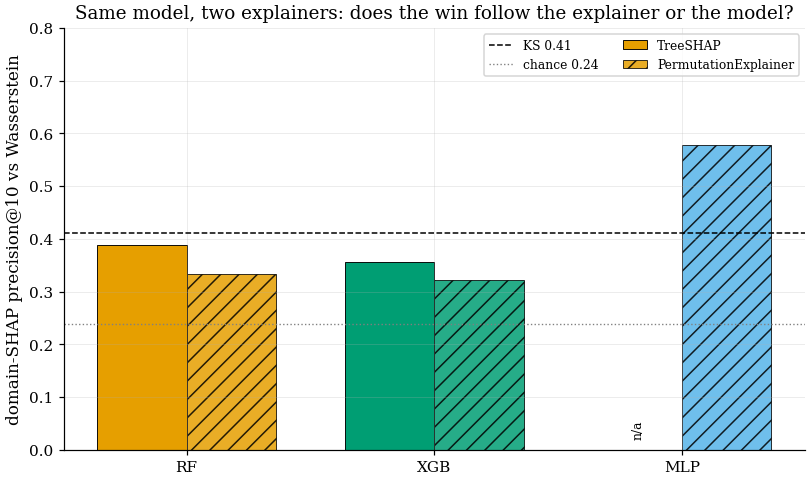

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))
x = np.arange(len(MODELS)); w = 0.36
tree_vals = [dom(mdl, 'treeshap') for mdl in MODELS]
perm_vals = [dom(mdl, 'perm') for mdl in MODELS]
ax.bar(x - w/2, [v if v == v else 0 for v in tree_vals], width=w, label='TreeSHAP',
       color=[MODEL_COLOR[mdl] for mdl in MODELS], edgecolor='black', linewidth=0.6)
ax.bar(x + w/2, perm_vals, width=w, label='PermutationExplainer', hatch='//',
       color=[MODEL_COLOR[mdl] for mdl in MODELS], edgecolor='black', linewidth=0.6, alpha=0.85)
ax.axhline(KS_MEAN, ls='--', color='black', lw=1.0, label=f'KS {KS_MEAN:.2f}')
ax.axhline(CHANCE, ls=':', color='grey', lw=0.9, label=f'chance {CHANCE:.2f}')
for xi, v in zip(x - w/2, tree_vals):
    if v != v:
        ax.text(xi, 0.02, 'n/a', ha='center', va='bottom', fontsize=8, rotation=90)
ax.set_xticks(x); ax.set_xticklabels([mdl.upper() for mdl in MODELS])
ax.set_ylabel(f'domain-SHAP precision@{K_PRIMARY} vs Wasserstein')
ax.set_ylim(0, 0.8)
ax.set_title('Same model, two explainers: does the win follow the explainer or the model?')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); save_figure(fig, '13b_explainer_control'); plt.show()

## 8. Save and log

In [9]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'purpose': 'isolate explainer vs model-class cause of the F018 MLP domain-SHAP advantage',
    'dataset': 'UNSW-NB15', 'construction': 'additive leave-one-family-out (as notebook 13)',
    'heldout_families': HELDOUT, 'models': MODELS, 'seeds': SEEDS, 'k': K_PRIMARY,
    'chance': CHANCE, 'ks_mean': KS_MEAN, 'margin': MARGIN,
    'by_model': summary,
    'ks_minus_domainshap_perm': {'rf': d_rf, 'xgb': d_xgb, 'mlp': d_mlp},
    'tree_perm_agreement': {mdl: float(ctrl[(ctrl['model'] == mdl) & (ctrl['variant'] == 'treeshap')]['agree_tree_perm'].mean())
                            for mdl in ('rf', 'xgb')},
    'verdict': verdict,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F019',
    title='Explainer control for the MLP domain-SHAP advantage (TreeSHAP vs PermutationExplainer on the same model)',
    context='05_phase3_generalization/13b_explainer_control',
    what_we_did=(
        'Controlled the F018 confound: for the same pre-vs-post domain classifier of each '
        'model class, computed domain-SHAP via TreeSHAP (RF/XGB) and the agnostic '
        'PermutationExplainer (RF/XGB/MLP) and scored precision@K vs the same Wasserstein '
        'anchor, on the notebook-13 arms. D031.'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. KS (model-free) %.3f. KS - domainSHAP under '
        'PermutationExplainer: rf %+.3f, xgb %+.3f, mlp %+.3f (negative = domain-SHAP beats '
        'KS). TreeSHAP baseline: rf %.3f, xgb %.3f (KS competitive, as in 13).'
        % (KS_MEAN, d_rf, d_xgb, d_mlp, summary['rf']['treeshap'], summary['xgb']['treeshap'])
    ),
    why_it_matters=(
        'Decides the paper wording for the neural result: whether the notebook-13 finding '
        '(domain-SHAP beats KS for the MLP) is an explainer-geometry effect or a genuine '
        'neural-model effect. Either way it is reported, not smoothed over; it sharpens the '
        'scope of C2 (KS competitive) rather than overturning the dual-adds-nothing core.'
    ),
)
print('F019 logged.')

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase3_13b_explainer_control.json
[FINDING LOGGED] F019: Explainer control for the MLP domain-SHAP advantage (TreeSHAP vs PermutationExplainer on the same model)
F019 logged.


## 9. What this settles

- **EXPLAINER-DRIVEN** -> C2 stands; the neural "advantage" is the marginal explainer
  aligning with the marginal anchor. Paper: one sentence noting explanation-vs-KS is
  explainer-dependent; with a path-dependent explainer (TreeSHAP) KS stays competitive.
- **MODEL-DRIVEN** -> a real model-class boundary. Paper: dual still adds nothing for all
  models (core intact); KS is competitive for tree explainers; a neural domain classifier
  localizes real drift better than the cheap test -- reported as a scoped refinement of C2.
- **MIXED** -> report the per-model deltas; avoid a clean dichotomy.

Either way this is the **last** experiment. Next is paper polish: fold 12 (three-family
Fig. 5), 13 (UNSW cross-model), and 13b (this control) into `paper.tex` with honest,
scoped wording, then notation/figures/reproducibility. No more models.

Record the call by hand:

In [10]:
# add_journal_entry(
#     title='Notebook 13b explainer control verdict',
#     body='...same domain classifier scored under TreeSHAP vs PermutationExplainer, the '
#          'KS-minus-domainSHAP deltas per model, the verdict (explainer- vs model-driven), '
#          'and how it scopes the wording of C2 in the paper.',
# )